# COMFORT Eval — Test01 Analysis

Paired-image MCQ, Image 1 = aligned perspective (`cam_back`), Image 2 = another viewpoint. 4-class relation prediction.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

RELATIONS = ["front", "behind", "left", "right"]

RELATION_MAP = {
    "infrontof": "front",
    "totheleft": "left",
    "totheright": "right",
    "behind": "behind",
}

TRUE_LABEL_GROUPS = {
    "front_behind": ["front", "behind"],
    "left_right":   ["left",  "right"],
}

OPPOSITE_RELATION = {"front": "behind", "behind": "front", "left": "right", "right": "left"}

# Test02: correct = always "front" (cam_pov_front).
# When wrong, model picked the distractor whose direction is relation-dependent:
#   front/behind -> cam_pov_back  -> "behind"
#   left         -> cam_pov_left  -> "left"
#   right        -> cam_pov_right -> "right"
TEST02_DISTRACTOR_DIRECTION = {
    "front":  "behind",
    "behind": "behind",
    "left":   "left",
    "right":  "right",
}

# ── Shared helpers ─────────────────────────────────────────────────────────

def extract_camera_perspective_comfort(image_path):
    image_path = str(image_path)
    parts = os.path.dirname(image_path).split("/")
    true_relation = parts[-2]
    folder_name = parts[-1]
    segments = folder_name.split("__")
    cam_segment = segments[-1]
    camera_position = cam_segment.split("_")[-1]

    camera_perspective = None
    if (true_relation == "behind" and camera_position == "left") or (true_relation == "infrontof" and camera_position == "right") or (true_relation == "totheleft" and camera_position == "front") or (true_relation == "totheright" and camera_position == "back"):
        camera_perspective = "right"
    elif (true_relation == "behind" and camera_position == "right") or (true_relation == "infrontof" and camera_position == "left") or (true_relation == "totheleft" and camera_position == "back") or (true_relation == "totheright" and camera_position == "front"):
        camera_perspective = "left"
    elif (true_relation == "behind" and camera_position == "front") or (true_relation == "infrontof" and camera_position == "back") or (true_relation == "totheleft" and camera_position == "right") or (true_relation == "totheright" and camera_position == "left"):
        camera_perspective = "behind"
    elif (true_relation == "behind" and camera_position == "back") or (true_relation == "infrontof" and camera_position == "front") or (true_relation == "totheleft" and camera_position == "left") or (true_relation == "totheright" and camera_position == "right"):
        camera_perspective = "front"
    return true_relation, camera_perspective


def extract_letter_to_relation(prompt):
    prompt = str(prompt)
    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue
        text = m.group(1).lower()
        if "front" in text:    mapping[letter] = "front"
        elif "behind" in text: mapping[letter] = "behind"
        elif "left" in text:   mapping[letter] = "left"
        elif "right" in text:  mapping[letter] = "right"
    return mapping


def plot_confusion_on_ax(df, ax, title, true_labels):
    plot_df = df[
        df["correct_relation"].isin(true_labels) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)

    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(true_labels)))
    ax.set_yticklabels(true_labels)
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, f"{cm_df.iloc[i, j]:.2f}", ha="center", va="center")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")


# ── Test01 loader ─────────────────────────────────────────────────────────

def load_and_prepare_pair(csv_path):
    df = pd.read_csv(csv_path)

    def get_pred_relation(row):
        return extract_letter_to_relation(row["mcq_prompt"]).get(str(row["pred_letter"]).strip(), None)

    df["pred_relation"] = df.apply(get_pred_relation, axis=1)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()

    r1 = df["image_path_1"].apply(extract_camera_perspective_comfort)
    r2 = df["image_path_2"].apply(extract_camera_perspective_comfort)
    df["object_position"]   = r1.apply(lambda x: RELATION_MAP.get(x[0], x[0]))
    df["cam_perspective_1"] = r1.apply(lambda x: x[1])
    df["cam_perspective_2"] = r2.apply(lambda x: x[1])

    df["cam_view_1"] = df["cam_view_1"].astype(str).str.strip()
    df["cam_view_2"] = df["cam_view_2"].astype(str).str.strip()
    df["view2_short"] = df["cam_view_2"].str.replace("cam_", "", regex=False)

    df["is_correct"]  = df["pred_letter"].astype(str).str.strip() == df["correct_letter"].astype(str).str.strip()
    df["is_opposite"] = df["pred_letter"].astype(str).str.strip() == df["opposite_letter"].astype(str).str.strip()
    return df


# ── Test02 loader ─────────────────────────────────────────────────────────

def load_and_prepare_pov(csv_path):
    df = pd.read_csv(csv_path)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()
    df["correct_relation"] = df["correct_relation"].map(RELATION_MAP).fillna(df["correct_relation"])
    df["is_correct"] = df["correct"].astype(str).str.lower().isin(["true", "1"])
    df["cam_view_external_short"] = df["cam_view_external"].str.replace("cam_", "", regex=False)
    return df


print("Helpers loaded.")

Helpers loaded.


---
## Test 01 — Aligned-First Pair MCQ

Image 1 = `cam_back` (aligned with person), Image 2 = another external viewpoint.  
4-class relation prediction (front / behind / left / right).

In [2]:
TEST01_DIR = "./results"
lengths    = ["short", "middle", "long"]
models01   = ["qwen3vl"]  # ← add more models here as results arrive

### 1 — Confusion matrices (short / middle / long)


===== MODEL: qwen3vl =====
  Loaded short: 120 rows  |  overall acc = 0.325
  Loaded middle: 120 rows  |  overall acc = 0.392
  Loaded long: 120 rows  |  overall acc = 0.317


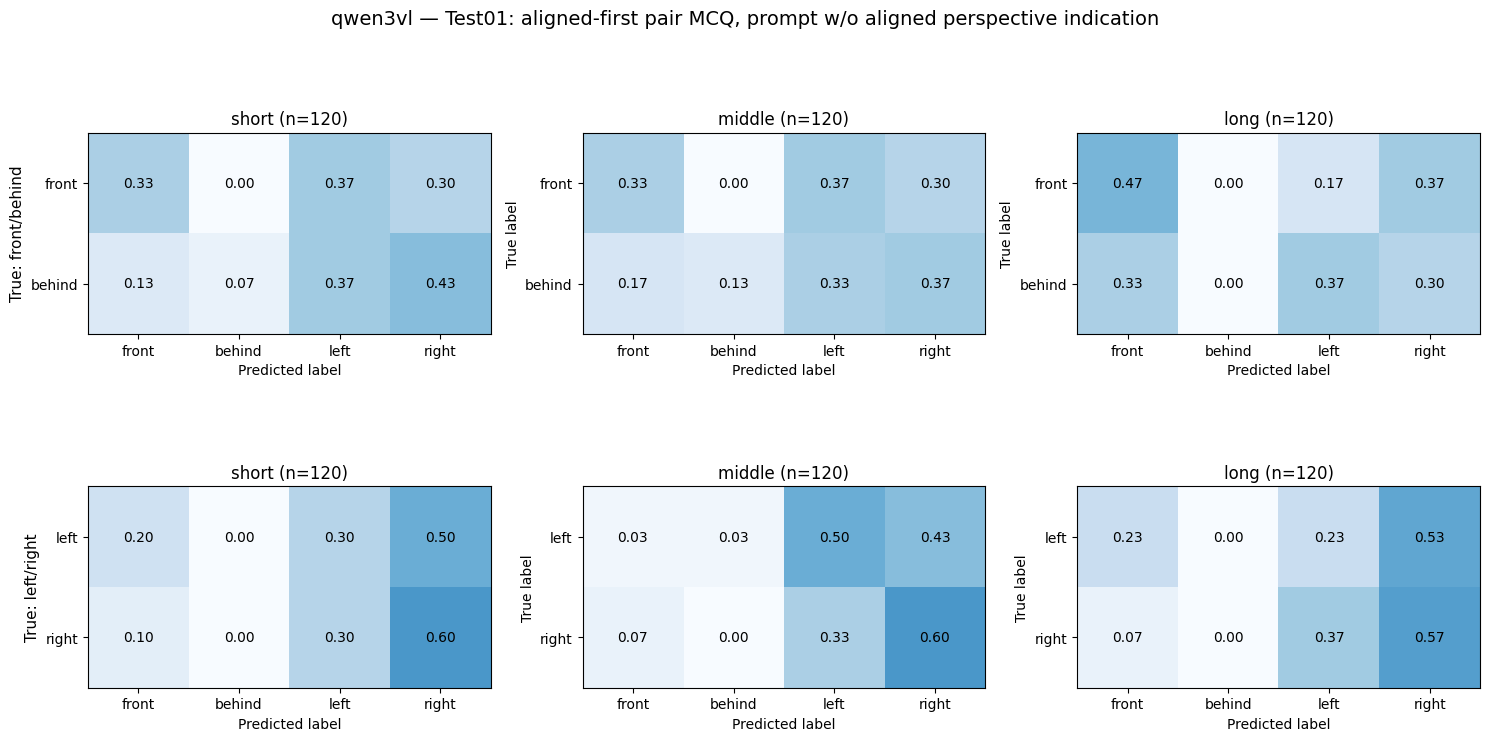

In [3]:
all_dfs_01 = defaultdict(dict) # rerun with a bit more complexed prompt - remove the "aligned perspective indication"

for model in models01:
    print(f"\n===== MODEL: {model} =====")
    dfs = {}

    for length in lengths:
        csv_path = os.path.join(TEST01_DIR, f"pair_mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"  Missing: {csv_path}")
            continue
        df = load_and_prepare_pair(csv_path)
        dfs[length] = df
        all_dfs_01[model][length] = df
        acc = df["is_correct"].mean()
        print(f"  Loaded {length}: {len(df)} rows  |  overall acc = {acc:.3f}")

    if not dfs:
        continue

    # Row 1: true = front/behind; Row 2: true = left/right; columns = short/middle/long
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[0][i].axis("off")
            axes[1][i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length], axes[0][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
        plot_confusion_on_ax(
            dfs[length], axes[1][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )

    axes[0][0].set_ylabel("True: front/behind", fontsize=11)
    axes[1][0].set_ylabel("True: left/right", fontsize=11)
    fig.suptitle(f"{model} — Test01: aligned-first pair MCQ, prompt w/o aligned perspective indication", fontsize=14)
    plt.tight_layout()
    plt.show()


===== MODEL: qwen3vl =====
  Loaded short: 120 rows  |  overall acc = 0.600
  Loaded middle: 120 rows  |  overall acc = 0.575
  Loaded long: 120 rows  |  overall acc = 0.567


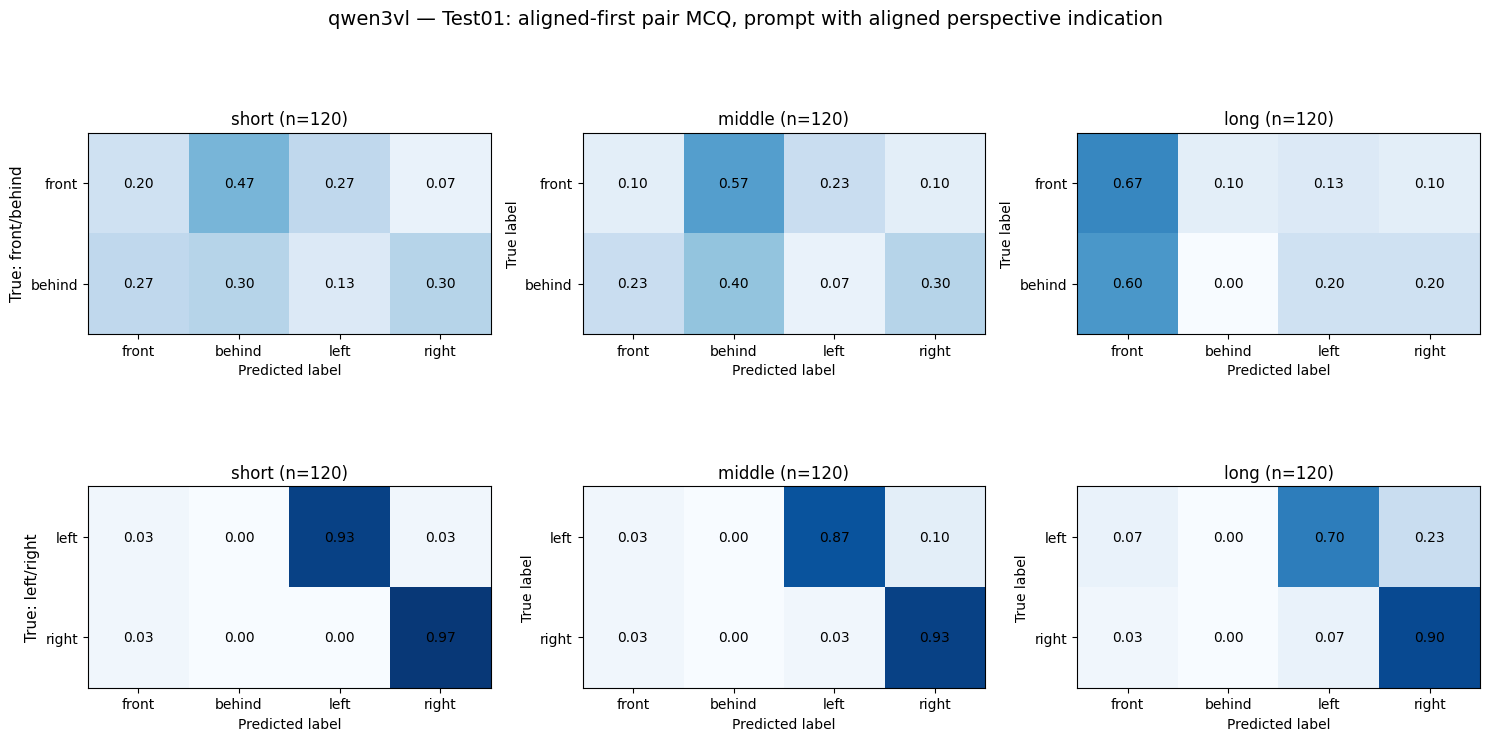

In [4]:
all_dfs_01 = defaultdict(dict)

for model in models01:
    print(f"\n===== MODEL: {model} =====")
    dfs = {}

    for length in lengths:
        csv_path = os.path.join(TEST01_DIR, f"pair_mcq_{length}_{model}_with'aligned'.csv")
        if not os.path.exists(csv_path):
            print(f"  Missing: {csv_path}")
            continue
        df = load_and_prepare_pair(csv_path)
        dfs[length] = df
        all_dfs_01[model][length] = df
        acc = df["is_correct"].mean()
        print(f"  Loaded {length}: {len(df)} rows  |  overall acc = {acc:.3f}")

    if not dfs:
        continue

    # Row 1: true = front/behind; Row 2: true = left/right; columns = short/middle/long
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, length in enumerate(lengths):
        if length not in dfs:
            axes[0][i].axis("off")
            axes[1][i].axis("off")
            continue
        plot_confusion_on_ax(
            dfs[length], axes[0][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["front_behind"]
        )
        plot_confusion_on_ax(
            dfs[length], axes[1][i],
            title=f"{length} (n={len(dfs[length])})",
            true_labels=TRUE_LABEL_GROUPS["left_right"]
        )

    axes[0][0].set_ylabel("True: front/behind", fontsize=11)
    axes[1][0].set_ylabel("True: left/right", fontsize=11)
    fig.suptitle(f"{model} — Test01: aligned-first pair MCQ, prompt with aligned perspective indication", fontsize=14)
    plt.tight_layout()
    plt.show()

### 2 — Accuracy by second-image view (cam_view_2)

Since Image 1 is always `cam_back`, the only variable is which view appears as Image 2.

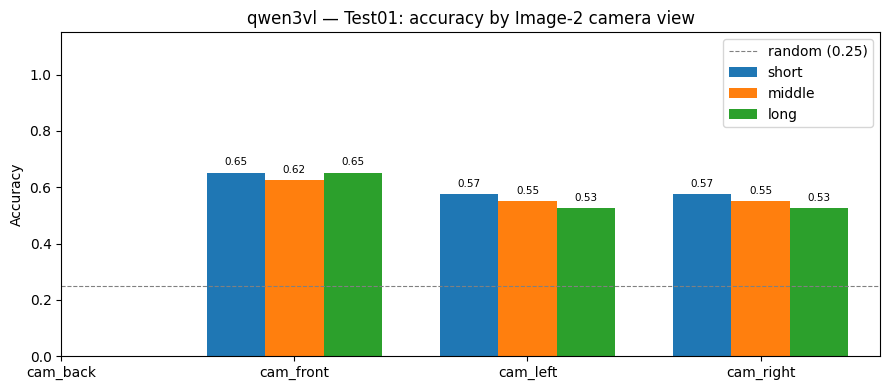

In [5]:
VIEW_SHORT = ["back", "front", "left", "right"]

for model in models01:
    if not all_dfs_01.get(model):
        continue

    available = [l for l in lengths if l in all_dfs_01[model]]
    x = np.arange(len(VIEW_SHORT))
    width = 0.25
    fig, ax = plt.subplots(figsize=(9, 4))

    for k, length in enumerate(available):
        df = all_dfs_01[model][length]
        accs = []
        for v in VIEW_SHORT:
            sub = df[df["view2_short"] == v]
            accs.append(sub["is_correct"].mean() if len(sub) > 0 else np.nan)
        bars = ax.bar(x + (k - len(available)/2 + 0.5) * width, accs, width, label=length)
        for bar, val in zip(bars, accs):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)

    ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, label="random (0.25)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"cam_{v}" for v in VIEW_SHORT])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{model} — Test01: accuracy by Image-2 camera view")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3 — Per-relation accuracy table (short / middle / long)

In [6]:
for model in models01:
    if not all_dfs_01.get(model):
        continue
    print(f"\n===== {model} =====")
    rows = []
    for length in lengths:
        if length not in all_dfs_01[model]:
            continue
        df = all_dfs_01[model][length]
        for rel in RELATIONS:
            sub = df[df["correct_relation"] == rel]
            acc = sub["is_correct"].mean() if len(sub) > 0 else np.nan
            rows.append({"length": length, "relation": rel, "n": len(sub), "accuracy": round(acc, 3)})
    tbl = pd.DataFrame(rows).pivot(index="relation", columns="length", values="accuracy")
    display(tbl)


===== qwen3vl =====


length,long,middle,short
relation,,,
behind,0.000,0.400,0.300
front,0.667,0.100,0.200
left,0.700,0.867,0.933
right,0.900,0.933,0.967
